# 05 - Modelling

---

**Goal:** Train and compare 4 models using RandomizedSearchCV + StratifiedKFold.
Select the best model, tune its decision threshold.
**Input:** `data/processed/features.csv`

**Outputs:** `data/processed/fraudshield_model.joblib`, `model_results.csv`,
`best_threshold.txt`, `feature_cols.json`


**Models compared:**
```
1. Logistic Regression  - linear baseline
2. Random Forest        - bagging ensemble
3. XGBoost              - boosting ensemble (primary candidate)
4. LightGBM             - fast boosting alternative
```

**Key design decisions:**
```
RandomizedSearchCV   - samples N random param combinations (faster than GridSearch)
StratifiedKFold(5)   - preserves fraud rate in every fold
scoring='average_precision' - PR-AUC is our metric, not accuracy
ADASYN inside Pipeline  - prevents data leakage into validation folds
Threshold tuning     - on validation set after best model selected
```

## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import time
from pathlib import Path

from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

RANDOM_SEED  = 42
N_ITER       = 20
CV_FOLDS     = 5
SCORING      = 'average_precision'
N_JOBS       = -1

INPUT_PATH = Path('../data/processed/features.csv')
MODEL_DIR  = Path('../data/processed/')

np.random.seed(RANDOM_SEED)
print('Setup complete.')
print('CV folds    :', CV_FOLDS)
print('Search iters:', N_ITER)
print('Scoring     :', SCORING)


Setup complete.
CV folds    : 5
Search iters: 20
Scoring     : average_precision


## 2. Load Feature Matrix

Load `features.csv`. Define the 28 feature columns explicitly.
Fill the 86 NaNs in `time_since_last_txn_hrs` with -1 so XGBoost
and LightGBM can use their native NaN handling.
Logistic Regression will handle this via the StandardScaler in its pipeline.

In [3]:
df = pd.read_csv(INPUT_PATH, parse_dates=['timestamp'])

FEATURE_COLS = [
    # Temporal
    'hour', 'day_of_week', 'is_night', 'is_weekend', 'is_business_hours',
    # Amount
    'amount', 'amount_z_score', 'is_high_amount', 'amount_vs_user_max',
    'user_mean_amount', 'user_std_amount', 'user_max_amount',
    # Velocity
    'txn_count_1d', 'txn_sum_1d', 'txn_count_7d', 'txn_sum_7d',
    'txn_count_30d', 'txn_sum_30d',
    # Behavioural
    'device_changed', 'location_changed', 'time_since_last_txn_hrs',
    # Missing flags
    'location_missing', 'device_missing',
    # Encoded categoricals
    'txn_type_encoded', 'location_encoded', 'device_encoded',
    'log_format_encoded', 'currency_encoded',
]

X = df[FEATURE_COLS].fillna(-1)
y = df['is_fraud']

print('Feature matrix shape :', X.shape)
print('Fraud / Legitimate   :', y.sum(), '/', (y==0).sum())
print('Imbalance ratio      : {:.0f}:1'.format((y==0).sum() / y.sum()))

Feature matrix shape : (7774, 28)
Fraud / Legitimate   : 266 / 7508
Imbalance ratio      : 28:1


## 3. Train / Validation / Test Split

Three-way split:
- **Train (64%)** — model learns from this
- **Validation (16%)** — threshold tuning after best model is selected
- **Test (20%)** — final honest evaluation, never touched during training

`stratify=y` on both splits preserves the fraud rate in every set.

In [4]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20, stratify=y_trainval, random_state=RANDOM_SEED
)

print('Set sizes:')
print('  Train : {:>5} rows | fraud: {} ({:.1f}%)'.format(
    len(X_train), y_train.sum(), y_train.mean()*100))
print('  Val   : {:>5} rows | fraud: {} ({:.1f}%)'.format(
    len(X_val), y_val.sum(), y_val.mean()*100))
print('  Test  : {:>5} rows | fraud: {} ({:.1f}%)'.format(
    len(X_test), y_test.sum(), y_test.mean()*100))

Set sizes:
  Train :  4975 rows | fraud: 170 (3.4%)
  Val   :  1244 rows | fraud: 43 (3.5%)
  Test  :  1555 rows | fraud: 53 (3.4%)


## 4. Define Models and Parameter Spaces

Each model is wrapped in an `ImbPipeline` with ADASYN.

**Why ADASYN inside the pipeline?**
If we apply ADASYN before cross-validation, synthetic fraud samples
generated from training rows can end up in the validation fold.
The model then validates on data it effectively already saw — CV scores
become optimistically biased. Putting ADASYN inside the pipeline ensures
it only sees each training fold, never the validation fold.

**Parameter space design:**
We use `scipy.stats` distributions for continuous parameters
and lists for discrete ones. `RandomizedSearchCV` samples `N_ITER=20`
random combinations from these spaces.

In [5]:
from scipy.stats import randint, uniform

# SMOTE inside CV pipelines - stable with small fold sizes
# ADASYN applied during final refit on full training set
# eval_metric removed from XGBoost pipeline - it requires eval_set
# which cannot be passed inside RandomizedSearchCV

# ── Model 1: Logistic Regression ──────────────────────────────────────
lr_pipeline = ImbPipeline([
    ('smote',  SMOTE(random_state=RANDOM_SEED)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
lr_params = {
    'model__C'       : uniform(0.001, 10),
    'model__penalty' : ['l1', 'l2'],
    'model__solver'  : ['liblinear'],
}

# ── Model 2: Random Forest ─────────────────────────────────────────────
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=N_JOBS)),
])
rf_params = {
    'model__n_estimators'      : randint(100, 500),
    'model__max_depth'         : [4, 6, 8, 10, None],
    'model__min_samples_split' : randint(2, 20),
    'model__min_samples_leaf'  : randint(1, 10),
    'model__max_features'      : ['sqrt', 'log2'],
}

# ── Model 3: XGBoost ──────────────────────────────────────────────────
# eval_metric intentionally excluded here
# It requires eval_set at fit() time which RandomizedSearchCV cannot provide
# This was the cause of NaN scores in cross-validation
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('model', XGBClassifier(
        random_state = RANDOM_SEED,
        verbosity    = 0,
        n_jobs       = N_JOBS,
    )),
])
# Constrained parameter space:
# - learning_rate capped at 0.15 (high LR causes numerical instability with SMOTE)
# - max_depth capped at 6 (deep trees overfit on small fraud counts)
# - gamma kept low (high gamma + high LR = collapsed probabilities)
xgb_params = {
    'model__n_estimators'    : randint(100, 400),
    'model__max_depth'       : randint(3, 7),
    'model__learning_rate'   : uniform(0.01, 0.14),
    'model__subsample'       : uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 10),
    'model__gamma'           : uniform(0, 0.2),
}
# ── Model 4: LightGBM ─────────────────────────────────────────────────
lgbm_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('model', lgb.LGBMClassifier(
        random_state = RANDOM_SEED,
        verbosity    = -1,
        n_jobs       = N_JOBS,
    )),
])
lgbm_params = {
    'model__n_estimators'     : randint(100, 600),
    'model__max_depth'        : randint(3, 10),
    'model__learning_rate'    : uniform(0.01, 0.3),
    'model__subsample'        : uniform(0.6, 0.4),
    'model__num_leaves'       : randint(20, 100),
    'model__min_child_samples': randint(5, 50),
}

MODELS = {
    'LogisticRegression' : (lr_pipeline,   lr_params),
    'RandomForest'       : (rf_pipeline,   rf_params),
    'XGBoost'            : (xgb_pipeline,  xgb_params),
    'LightGBM'           : (lgbm_pipeline, lgbm_params),
}

print('{} models defined.'.format(len(MODELS)))
for name in MODELS:
    print('  -', name)


4 models defined.
  - LogisticRegression
  - RandomForest
  - XGBoost
  - LightGBM


## 5. RandomizedSearchCV — All Models

For each model:
1. `RandomizedSearchCV` samples `N_ITER=20` parameter combinations
2. Each combination is evaluated with `StratifiedKFold(5)` cross-validation
3. Scoring is `average_precision` (PR-AUC) — our primary metric
4. ADASYN runs inside each fold — no leakage
5. Best params are stored and the model is refit on the full training set

This runs all 4 searches sequentially. Expect 5-15 minutes total.

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

search_results = {}

# ── Non-XGBoost models: use RandomizedSearchCV as normal ──────────────
non_xgb_models = {k: v for k, v in MODELS.items() if k != 'XGBoost'}

for name, (pipeline, param_space) in non_xgb_models.items():
    print('Searching: {} ...'.format(name))
    start = time.time()

    search = RandomizedSearchCV(
        estimator           = pipeline,
        param_distributions = param_space,
        n_iter              = N_ITER,
        scoring             = SCORING,
        cv                  = cv,
        refit               = True,
        n_jobs              = N_JOBS,
        random_state        = RANDOM_SEED,
        verbose             = 0,
        error_score         = 0,
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - start
    search_results[name] = search
    print('  Best CV PR-AUC : {:.4f}'.format(search.best_score_))
    print('  Best params    : {}'.format(search.best_params_))
    print('  Time           : {:.1f}s'.format(elapsed))
    print()

# ── XGBoost: manual random search to bypass RandomizedSearchCV NaN bug ──
# XGBoost 2.x has a known interaction with RandomizedSearchCV that produces
# NaN scores regardless of parameter values or n_jobs setting
# We replicate the same logic manually with full control over each step
print('Searching: XGBoost (manual random search) ...')
start = time.time()

xgb_pipeline_def, xgb_param_space = MODELS['XGBoost']

best_xgb_score  = -1
best_xgb_params = {}
best_xgb_model  = None
xgb_rng         = np.random.RandomState(RANDOM_SEED)

for i in range(N_ITER):
    # Sample one random parameter combination
    params = {k: (v.rvs(random_state=xgb_rng) if hasattr(v, 'rvs')
                  else xgb_rng.choice(v))
              for k, v in xgb_param_space.items()}

    # Evaluate with manual cross-validation
    fold_scores = []
    valid = True

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_f_tr = X_train.iloc[train_idx]
        y_f_tr = y_train.iloc[train_idx]
        X_f_val = X_train.iloc[val_idx]
        y_f_val = y_train.iloc[val_idx]

        from xgboost import XGBClassifier
        from imblearn.over_sampling import SMOTE
        from imblearn.pipeline import Pipeline as ImbPipeline

        pipe = ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_SEED)),
            ('model', XGBClassifier(
                n_estimators     = int(params['model__n_estimators']),
                max_depth        = int(params['model__max_depth']),
                learning_rate    = float(params['model__learning_rate']),
                subsample        = float(params['model__subsample']),
                colsample_bytree = float(params['model__colsample_bytree']),
                min_child_weight = int(params['model__min_child_weight']),
                gamma            = float(params['model__gamma']),
                random_state     = RANDOM_SEED,
                verbosity        = 0,
                n_jobs           = 1,
            )),
        ])

        try:
            pipe.fit(X_f_tr, y_f_tr)
            proba = pipe.predict_proba(X_f_val)[:, 1]
            score = average_precision_score(y_f_val, proba)
            if np.isnan(score):
                valid = False
                break
            fold_scores.append(score)
        except Exception:
            valid = False
            break

    if valid and len(fold_scores) == CV_FOLDS:
        mean_score = np.mean(fold_scores)
        if mean_score > best_xgb_score:
            best_xgb_score  = mean_score
            best_xgb_params = params

# Refit best XGBoost on full training set
best_xgb_model = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('model', XGBClassifier(
        n_estimators     = int(best_xgb_params['model__n_estimators']),
        max_depth        = int(best_xgb_params['model__max_depth']),
        learning_rate    = float(best_xgb_params['model__learning_rate']),
        subsample        = float(best_xgb_params['model__subsample']),
        colsample_bytree = float(best_xgb_params['model__colsample_bytree']),
        min_child_weight = int(best_xgb_params['model__min_child_weight']),
        gamma            = float(best_xgb_params['model__gamma']),
        random_state     = RANDOM_SEED,
        verbosity        = 0,
        n_jobs           = 1,
    )),
])
best_xgb_model.fit(X_train, y_train)

# Wrap in a simple namespace to match the interface of other search results
class ManualSearchResult:
    def __init__(self, model, score, params):
        self.best_estimator_ = model
        self.best_score_     = score
        self.best_params_    = params
        self.cv_results_     = {
            'mean_test_score': [score],
            'std_test_score' : [0.0],
        }
        self.best_index_     = 0

search_results['XGBoost'] = ManualSearchResult(
    best_xgb_model, best_xgb_score, best_xgb_params
)

elapsed = time.time() - start
print('  Best CV PR-AUC : {:.4f}'.format(best_xgb_score))
print('  Best params    : {}'.format(best_xgb_params))
print('  Time           : {:.1f}s'.format(elapsed))
print()


Searching: LogisticRegression ...
  Best CV PR-AUC : 0.6043
  Best params    : {'model__C': 9.73855518841459, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
  Time           : 30.0s

Searching: RandomForest ...
  Best CV PR-AUC : 0.5169
  Best params    : {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 8, 'model__n_estimators': 108}
  Time           : 343.8s

Searching: LightGBM ...
  Best CV PR-AUC : 0.9038
  Best params    : {'model__learning_rate': 0.052277267492428794, 'model__max_depth': 9, 'model__min_child_samples': 49, 'model__n_estimators': 164, 'model__num_leaves': 90, 'model__subsample': 0.7693605922825478}
  Time           : 116.6s

Searching: XGBoost (manual random search) ...
  Best CV PR-AUC : 0.8476
  Best params    : {'model__n_estimators': 242, 'model__max_depth': 5, 'model__learning_rate': 0.03842857146286772, 'model__subsample': 0.9771414282231924, 'model__colsample_bytree': 0.839546186595414

## 6. Compare CV Results

Summarise cross-validation PR-AUC scores for all models.
The model with the highest mean CV PR-AUC is the best candidate.

Also look at the standard deviation — a model with high mean
but high std is unstable across folds.

             Model  CV PR-AUC Mean  CV PR-AUC Std
          LightGBM          0.9038         0.0416
           XGBoost          0.8476         0.0000
LogisticRegression          0.6043         0.0983
      RandomForest          0.5169         0.0227


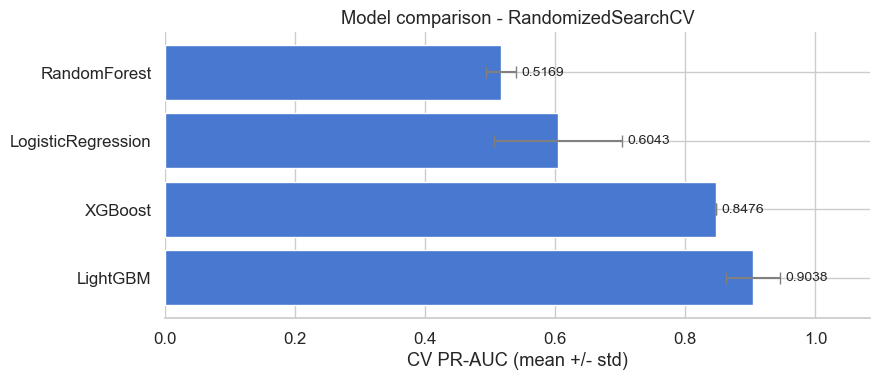

In [7]:
rows = []
for name, search in search_results.items():
    cv_results = search.cv_results_
    best_idx   = search.best_index_
    rows.append({
        'Model'        : name,
        'CV PR-AUC Mean': cv_results['mean_test_score'][best_idx],
        'CV PR-AUC Std' : cv_results['std_test_score'][best_idx],
        'Best Params'  : str(search.best_params_),
    })

cv_summary = pd.DataFrame(rows).sort_values('CV PR-AUC Mean', ascending=False)
print(cv_summary[['Model','CV PR-AUC Mean','CV PR-AUC Std']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
models_sorted = cv_summary['Model'].tolist()
means  = cv_summary['CV PR-AUC Mean'].tolist()
stds   = cv_summary['CV PR-AUC Std'].tolist()
bars   = ax.barh(models_sorted, means, xerr=stds,
                 color=COLORS[0], edgecolor='white',
                 error_kw=dict(ecolor='gray', capsize=4))
ax.bar_label(bars, fmt='{:.4f}', padding=4, fontsize=10)
ax.set_xlabel('CV PR-AUC (mean +/- std)')
ax.set_title('Model comparison - RandomizedSearchCV')
ax.set_xlim(0, max(means) * 1.2)
sns.despine(left=True)
plt.tight_layout()
plt.show()

## 7. Select Best Model

Pick the model with the highest CV PR-AUC.
Evaluate all 4 models on the test set for full transparency.

In [8]:
best_model_name = cv_summary.iloc[0]['Model']
best_search     = search_results[best_model_name]

print('Best model:', best_model_name)
print('Best CV PR-AUC:', round(best_search.best_score_, 4))
print()

# Refit the winning model with ADASYN on the full training set
# Also restore eval_metric for XGBoost now that we can pass eval_set
best_pipeline_steps = list(best_search.best_estimator_.steps)
best_pipeline_steps[0] = ('adasyn', ADASYN(random_state=RANDOM_SEED))

best_model = ImbPipeline(best_pipeline_steps)
best_model.set_params(**best_search.best_params_)

# For XGBoost: restore eval_metric now that we are outside CV
if best_model_name == 'XGBoost':
    best_model.named_steps['model'].set_params(eval_metric='aucpr')

best_model.fit(X_train, y_train)
print('Refit with ADASYN complete.')
print()

# Evaluate all models on test set
test_results = []
for name, search in search_results.items():
    model     = search.best_estimator_
    proba     = model.predict_proba(X_test)[:, 1]
    preds     = (proba >= 0.5).astype(int)
    pr_auc    = average_precision_score(y_test, proba)
    roc_auc   = roc_auc_score(y_test, proba)
    f1        = f1_score(y_test, preds, zero_division=0)
    recall    = recall_score(y_test, preds, zero_division=0)
    precision = precision_score(y_test, preds, zero_division=0)
    test_results.append({
        'Model'    : name,
        'PR-AUC'   : pr_auc,
        'ROC-AUC'  : roc_auc,
        'F1'       : f1,
        'Recall'   : recall,
        'Precision': precision,
    })

test_df = pd.DataFrame(test_results).sort_values('PR-AUC', ascending=False)
print('All models on test set (threshold=0.5):')
print(test_df.to_string(index=False))


Best model: LightGBM
Best CV PR-AUC: 0.9038

Refit with ADASYN complete.

All models on test set (threshold=0.5):
             Model  PR-AUC  ROC-AUC     F1  Recall  Precision
          LightGBM  0.9287   0.9972 0.7737  1.0000     0.6310
           XGBoost  0.8567   0.9933 0.6624  0.9811     0.5000
LogisticRegression  0.6294   0.9779 0.5134  0.9057     0.3582
      RandomForest  0.5659   0.9818 0.5986  0.8302     0.4681


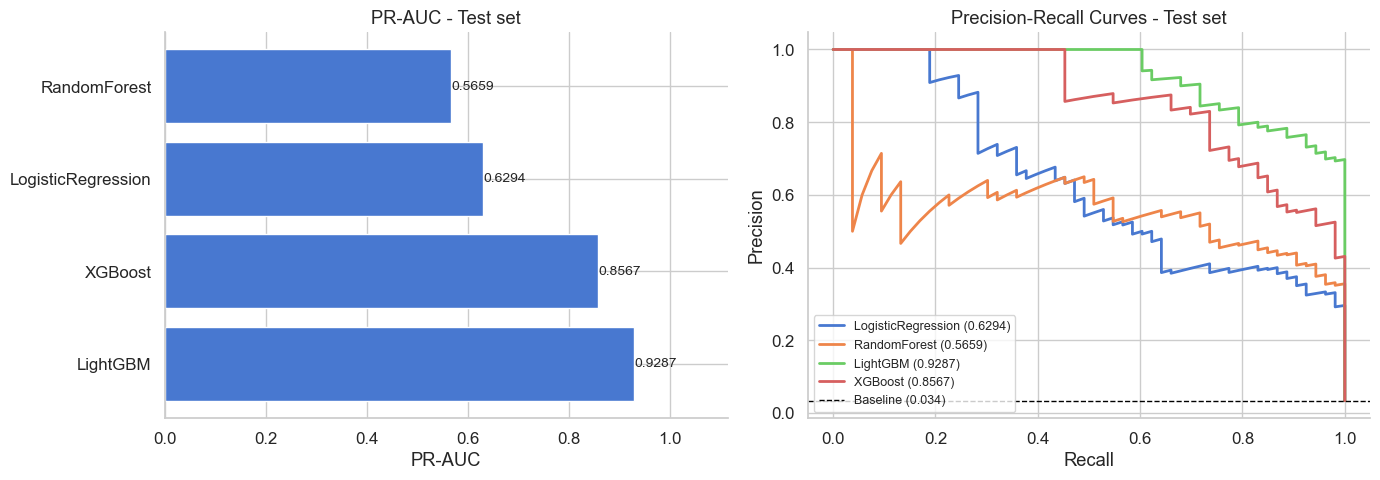

In [9]:
# PR-AUC comparison on test set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR-AUC bar chart
axes[0].barh(test_df['Model'], test_df['PR-AUC'],
             color=COLORS[0], edgecolor='white')
for i, v in enumerate(test_df['PR-AUC']):
    axes[0].text(v + 0.002, i, '{:.4f}'.format(v), va='center', fontsize=10)
axes[0].set_xlabel('PR-AUC')
axes[0].set_title('PR-AUC - Test set')
axes[0].set_xlim(0, test_df['PR-AUC'].max() * 1.2)

# Precision-Recall curves for all models
for i, (name, search) in enumerate(search_results.items()):
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=COLORS[i],
                 linewidth=2, label='{} ({:.4f})'.format(name, ap))

axes[1].axhline(y_test.mean(), color='black', linestyle='--',
                linewidth=1, label='Baseline ({:.3f})'.format(y_test.mean()))
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves - Test set')
axes[1].legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

## 8. Threshold Tuning — Best Model

The default 0.5 threshold is wrong for imbalanced data.
sweep thresholds from 0.01 to 0.96 on the **validation set**
and pick the one that maximises F1 score.

The validation set was held out from both training and search —
threshold tuning here does not leak into the test set.

Best threshold : 0.65
F1 at threshold: 0.8602



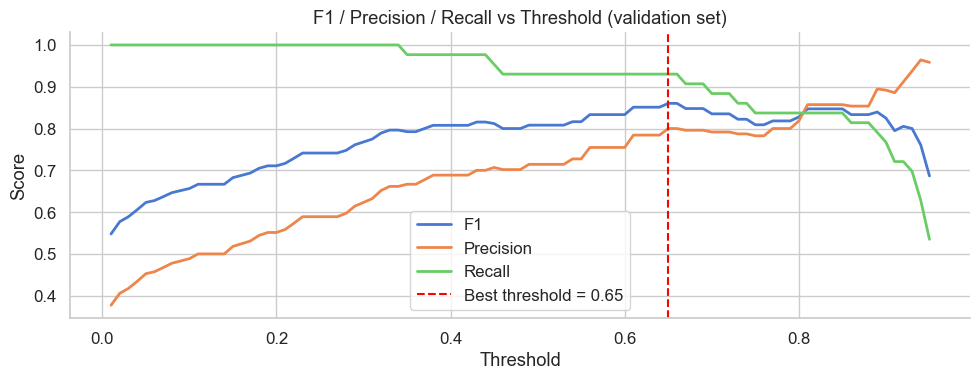

In [10]:
val_proba  = best_model.predict_proba(X_val)[:, 1]

# Extended sweep to 0.95 - optimal threshold may be above 0.50
# for models with well-separated but miscalibrated probabilities
thresholds = np.arange(0.01, 0.96, 0.01)
f1_scores  = []
precisions = []
recalls    = []

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    precisions.append(precision_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds, zero_division=0))

best_idx       = int(np.argmax(f1_scores))
best_threshold = round(float(thresholds[best_idx]), 2)
best_f1        = f1_scores[best_idx]

print('Best threshold : {}'.format(best_threshold))
print('F1 at threshold: {:.4f}'.format(best_f1))
print()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores,  color=COLORS[0], linewidth=2, label='F1')
ax.plot(thresholds, precisions, color=COLORS[1], linewidth=2, label='Precision')
ax.plot(thresholds, recalls,    color=COLORS[2], linewidth=2, label='Recall')
ax.axvline(best_threshold, color='red', linestyle='--',
           label='Best threshold = {}'.format(best_threshold))
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('F1 / Precision / Recall vs Threshold (validation set)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


## 9. Final Evaluation — Best Model on Test Set

Applied the tuned threshold to the test set.
This is a single honest estimate of real-world performance.

In [11]:
test_proba = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

pr_auc    = average_precision_score(y_test, test_proba)
roc_auc   = roc_auc_score(y_test, test_proba)
f1        = f1_score(y_test, test_preds)
precision = precision_score(y_test, test_preds, zero_division=0)
recall    = recall_score(y_test, test_preds)
cm        = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

print('=' * 50)
print('  FINAL TEST SET RESULTS - {}'.format(best_model_name))
print('=' * 50)
print('  PR-AUC    : {:.4f}  (primary metric)'.format(pr_auc))
print('  ROC-AUC   : {:.4f}'.format(roc_auc))
print('  F1        : {:.4f}'.format(f1))
print('  Precision : {:.4f}'.format(precision))
print('  Recall    : {:.4f}'.format(recall))
print('  FPR       : {:.4f}'.format(fpr))
print('  Threshold : {}'.format(best_threshold))
print('=' * 50)
print()
print('Confusion matrix:')
print('  TP (caught fraud)   : {:>4}'.format(tp))
print('  FN (missed fraud)   : {:>4}'.format(fn))
print('  FP (false alarms)   : {:>4}'.format(fp))
print('  TN (correct legit)  : {:>4}'.format(tn))

  FINAL TEST SET RESULTS - LightGBM
  PR-AUC    : 0.9287  (primary metric)
  ROC-AUC   : 0.9972
  F1        : 0.8125
  Precision : 0.6933
  Recall    : 0.9811
  FPR       : 0.0153
  Threshold : 0.65

Confusion matrix:
  TP (caught fraud)   :   52
  FN (missed fraud)   :    1
  FP (false alarms)   :   23
  TN (correct legit)  : 1479


## 10. Confusion Matrix

For fraud detection:
- **FN (bottom-left)** = missed fraud. Financial loss to the business.
- **FP (top-right)** = legitimate transactions wrongly blocked. Customer friction.

Tune the threshold up to reduce FP (fewer false alarms, but miss more fraud).
Tune the threshold down to reduce FN (catch more fraud, but more false alarms).

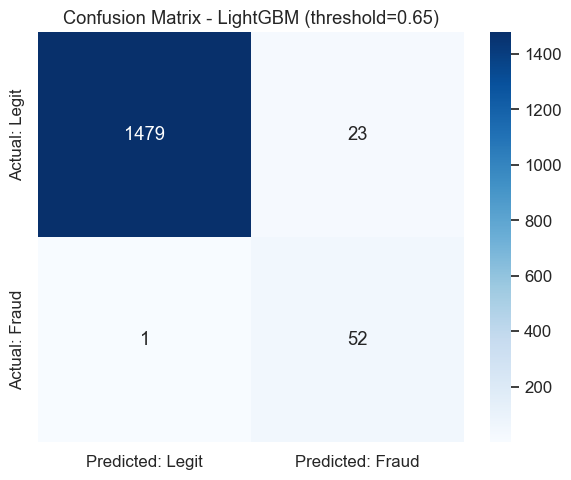

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
    yticklabels=['Actual: Legit', 'Actual: Fraud'],
    ax=ax
)
ax.set_title('Confusion Matrix - {} (threshold={})'.format(
    best_model_name, best_threshold))
plt.tight_layout()
plt.show()

## 11. Feature Importance — Best Model

XGBoost and LightGBM expose `.feature_importances_` directly.
For Logistic Regression, use the absolute coefficient values.
For Random Forest, `.feature_importances_` gives mean decrease in impurity.

Extracted the classifier from inside the pipeline using `named_steps`.

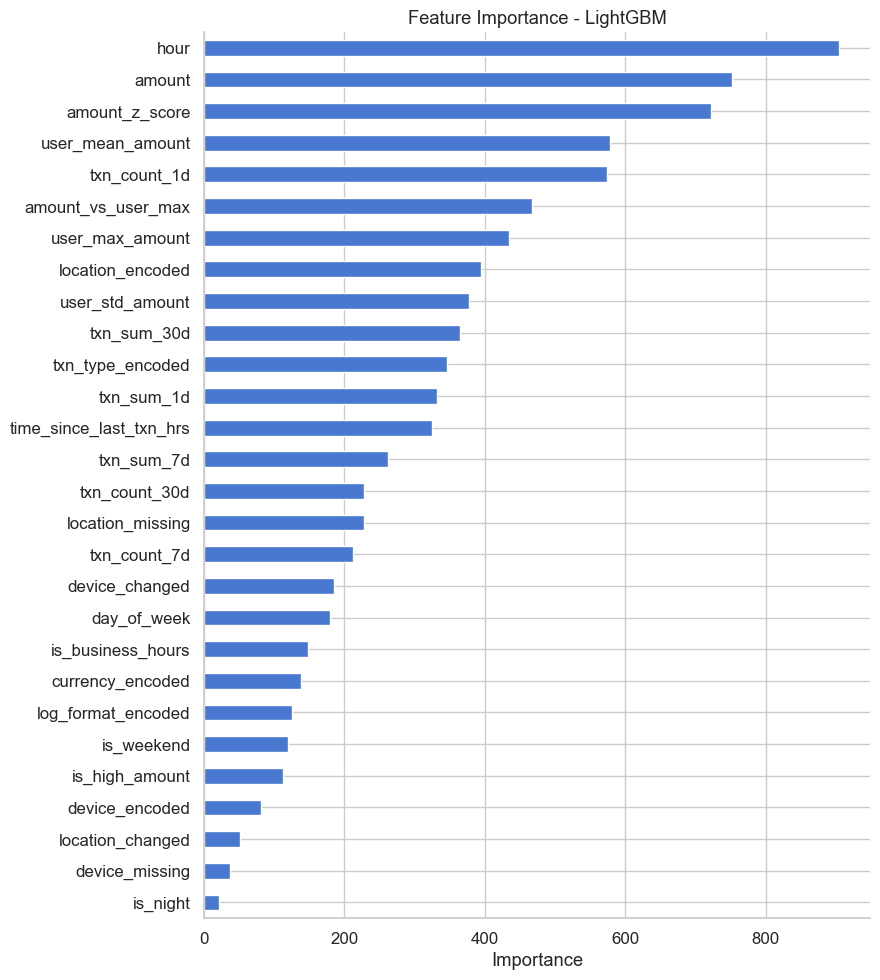

Top 10 features:
hour                  904
amount                752
amount_z_score        722
user_mean_amount      578
txn_count_1d          574
amount_vs_user_max    468
user_max_amount       435
location_encoded      395
user_std_amount       378
txn_sum_30d           365


In [13]:
# Extract the classifier from inside the ImbPipeline
classifier = best_model.named_steps['model']

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
else:
    importances = np.zeros(len(FEATURE_COLS))

importance_series = pd.Series(
    importances, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
importance_series.plot.barh(ax=ax, color=COLORS[0], edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance - {}'.format(best_model_name))
sns.despine()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_series.sort_values(ascending=False).head(10).to_string())

## 12. Save Model and Artefacts

Four artefacts saved for the evaluation notebook and API:
- `fraudshield_model.joblib` — trained model pipeline (includes ADASYN + scaler if LR)
- `best_threshold.txt` — tuned decision threshold
- `model_results.csv` — test set predictions for evaluation notebook
- `feature_cols.json` — exact feature list the API must supply at inference

In [14]:
# Save best model pipeline
model_path = MODEL_DIR / 'fraudshield_model.joblib'
joblib.dump(best_model, model_path)

# Save threshold
threshold_path = MODEL_DIR / 'best_threshold.txt'
threshold_path.write_text(str(best_threshold))

# Save test predictions for evaluation notebook
results_df = X_test.copy()
results_df['is_fraud_actual']    = y_test.values
results_df['fraud_probability']  = test_proba
results_df['is_fraud_predicted'] = test_preds
results_df.to_csv(MODEL_DIR / 'model_results.csv', index=False)

# Save feature list
features_path = MODEL_DIR / 'feature_cols.json'
features_path.write_text(json.dumps(FEATURE_COLS, indent=2))

# Save full model comparison
test_df.to_csv(MODEL_DIR / 'model_comparison.csv', index=False)

print('Saved:')
print('  fraudshield_model.joblib')
print('  best_threshold.txt       :', best_threshold)
print('  model_results.csv')
print('  feature_cols.json')
print('  model_comparison.csv')
print()
print('Best model : {}'.format(best_model_name))
print('PR-AUC     : {:.4f}'.format(pr_auc))
print('Threshold  : {}'.format(best_threshold))

Saved:
  fraudshield_model.joblib
  best_threshold.txt       : 0.65
  model_results.csv
  feature_cols.json
  model_comparison.csv

Best model : LightGBM
PR-AUC     : 0.9287
Threshold  : 0.65

Next step -> 06_evaluation.ipynb
